# Projekt 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych

**Autorzy**: Kalina Rączka, Emilia Sarna

**Data**: 21.05.2026

## Na 4

### Charakterystyka wybranego środowiska

LunarLanderContinuous-v2 to srodowisko z przestrzenia stanow ciaglych (8 cech: polozenie ladera, predkosci, kat, predkosc katowa oraz kontakty nozek z podlozem) i akcjami ciaglymi (2 silniki w zakresie [-1, 1]).
Nagroda jest ksztaltowana (shaping) i zalezy od stabilnosci lotu, bliskosci platformy oraz bezpiecznego ladowania. Epizod konczy sie po wyladowaniu, rozbiciu lub opuszczeniu obszaru.

### Charakterystyka algortymu

Zastosowalam trzy algorytmy ze stable-baselines3 przystosowane do sterowania w przestrzeniach ciaglych: PPO (on-policy), SAC i TD3 (off-policy).
PPO zapewnia stabilne uczenie z ograniczeniem kroku polityki, SAC dodaje regularizacje entropii i zwykle szybciej eksploruje, a TD3 zmniejsza przeszacowanie wartosci Q przez podwojony krytyk.
W raporcie porownuje krzywe uczenia miedzy zestawami hiperparametrow w ramach kazdego algorytmu.

### Wybrane hiperparametry

Dla kazdego algorytmu przygotowano trzy zestawy hiperparametrow (minimum wymagane w poleceniu).
Kazdy zestaw uruchamiany jest 10 razy po 50 000 krokow czasowych. Raport zawiera srednie i odchylenia oraz pomiar czasu na krok i epizod.

In [1]:
from pathlib import Path
import json

RESULTS_DIR = Path("results")

def _fmt(value, ndigits=3):
    if value is None:
        return "n/a"
    return f"{value:.{ndigits}f}"

def load_config_rows():
    rows = []
    for summary_path in RESULTS_DIR.rglob("summary.json"):
        algo = summary_path.parent.parent.name
        config = summary_path.parent.name
        with open(summary_path, "r", encoding="utf-8") as file:
            summary = json.load(file)
        params_path = summary_path.parent / "params.json"
        params = {}
        if params_path.exists():
            with open(params_path, "r", encoding="utf-8") as file:
                params = json.load(file)
        rows.append(
            {
                "algo": algo,
                "config": config,
                "mean_reward": summary.get("mean_reward"),
                "std_reward": summary.get("std_reward"),
                "mean_last_25%": summary.get("mean_last_25%"),
                "time_step": summary.get("avg_time_per_timestep_sec"),
                "time_episode": summary.get("avg_time_per_episode_sec"),
                "params": params.get("params", {}),
            }
        )
    return rows

rows = load_config_rows()
for row in sorted(rows, key=lambda r: (r["algo"], r["config"])):
    print(
        f"{row['algo']:>3} | {row['config']:<8} | "
        f"mean={_fmt(row['mean_reward'], 1)} +/- {_fmt(row['std_reward'], 1)} | "
        f"last25={_fmt(row['mean_last_25%'], 1)}"
    )
    print(
        f"    time_step={_fmt(row['time_step'], 6)}s, "
        f"time_episode={_fmt(row['time_episode'], 4)}s"
    )
    print(f"    params={row['params']}")
    print("")

PPO | ppo_a    | mean=-133.2 +/- 128.1 | last25=-135.7
    time_step=0.000203s, time_episode=0.0410s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.95, 'batch_size': 256, 'n_steps': 2048, 'ent_coef': 0.0}

PPO | ppo_b    | mean=-169.8 +/- 137.1 | last25=-150.4
    time_step=0.000183s, time_episode=0.0393s
    params={'learning_rate': 0.001, 'gamma': 0.98, 'gae_lambda': 0.9, 'batch_size': 512, 'n_steps': 2048, 'ent_coef': 0.01}

PPO | ppo_c    | mean=-156.1 +/- 111.2 | last25=-151.0
    time_step=0.000198s, time_episode=0.0241s
    params={'learning_rate': 0.0001, 'gamma': 0.995, 'gae_lambda': 0.98, 'batch_size': 256, 'n_steps': 4096, 'ent_coef': 0.0}

SAC | sac_a    | mean=-83.9 +/- 145.8 | last25=-94.1
    time_step=0.002520s, time_episode=1.6369s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'tau': 0.005, 'batch_size': 256, 'buffer_size': 300000, 'train_freq': 1, 'gradient_steps': 1}

SAC | sac_b    | mean=-66.0 +/- 176.4 | last25=-85.8
    time_step=0.0031

### Krzywe uczenia

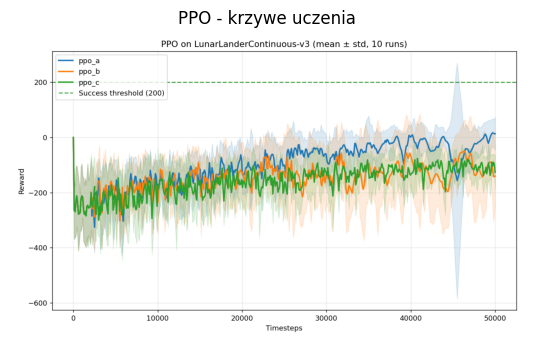

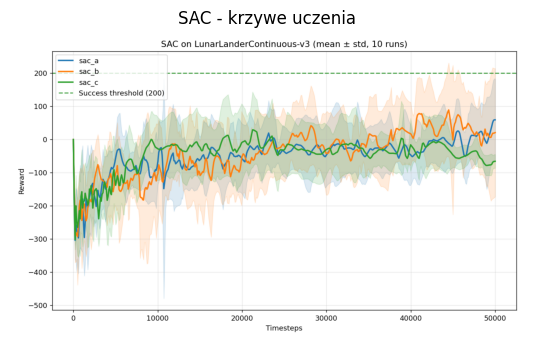

Brak wykresu dla TD3: results/TD3/comparison_curve.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for algo in ["PPO", "SAC", "TD3"]:
    curve_path = RESULTS_DIR / algo / "comparison_curve.png"
    if not curve_path.exists():
        print(f"Brak wykresu dla {algo}: {curve_path}")
        continue
    img = mpimg.imread(curve_path)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{algo} - krzywe uczenia")
    plt.show()

## Na 6

### Dwie architektury

Porownanie architektur wykonano dla SAC, przy tych samych hiperparametrach. Uzyto dwoch MLP z aktywacja ReLU:
- small: 2 warstwy ukryte po 64 neurony
- large: 2 warstwy ukryte po 256 neuronow

Wejscie sieci aktora to stan (8 cech), a wyjscie to akcja ciagla (2 wymiary). Krytyk otrzymuje stan i akcje, a na wyjsciu zwraca wartosc Q (skalar).

```mermaid
graph LR
  S[Stan 8] --> H1[64] --> H2[64] --> A[Akcja 2]
  SA[Stan+Akcja] --> C1[64] --> C2[64] --> Q[Q(s,a)]
```

```mermaid
graph LR
  S2[Stan 8] --> H1b[256] --> H2b[256] --> A2[Akcja 2]
  SA2[Stan+Akcja] --> C1b[256] --> C2b[256] --> Q2[Q(s,a)]
```

## Na 8

### Symulacje

Najlepszy agent (wg sredniej z ostatnich 25% epizodow) jest zapisywany do results/best_model. Symulacje uruchamiane sa deterministycznie, bez eksploracji.

In [3]:
best_dir = RESULTS_DIR / "best_model"
info_path = best_dir / "best_model_info.json"
eval_path = best_dir / "eval.json"

if info_path.exists():
    with open(info_path, "r", encoding="utf-8") as file:
        info = json.load(file)
    print("Best model:", info)
else:
    print("Brak best_model_info.json")

if eval_path.exists():
    with open(eval_path, "r", encoding="utf-8") as file:
        eval_data = json.load(file)
    print("Eval rewards:", eval_data.get("rewards", []))
    print(f"Eval mean: {eval_data.get('mean'):.1f} ± {eval_data.get('std'):.1f}")
else:
    print("Brak eval.json")

Brak best_model_info.json
Brak eval.json


### Krzywa uczenia i nagrody

In [4]:
def load_curve(algo_name, config_name):
    curve_path = RESULTS_DIR / algo_name / config_name / "curve.json"
    if not curve_path.exists():
        return None
    with open(curve_path, "r", encoding="utf-8") as file:
        return json.load(file)

eval_data = {}
if eval_path.exists():
    with open(eval_path, "r", encoding="utf-8") as file:
        eval_data = json.load(file)

if info_path.exists():
    algo_name = info.get("algorithm")
    config_name = info.get("hyperparam_set")
    curve = load_curve(algo_name, config_name)
    if curve is None:
        print("Brak curve.json dla najlepszego modelu")
    else:
        plt.figure(figsize=(8, 4))
        plt.plot(curve["timesteps"], curve["mean"], label="mean reward")
        lower = [m - s for m, s in zip(curve["mean"], curve["std"]) ]
        upper = [m + s for m, s in zip(curve["mean"], curve["std"]) ]
        plt.fill_between(curve["timesteps"], lower, upper, alpha=0.2, label="std")
        if eval_data:
            plt.axhline(eval_data.get("mean", 0.0), color="red", linestyle="--", label="eval mean")
        plt.title(f"{algo_name} - krzywa uczenia vs. ewaluacja")
        plt.xlabel("Timesteps")
        plt.ylabel("Reward")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()